# NSGA-II Training Analysis — night_run_v2

This notebook analyses the training logs from the NSGA-II neuroevolution run and produces publication-ready figures for the report.

**Run:** `night_run_v2` — 202 generations, ~5h30, 27 workers  
**Objectives:** speed (cumulative reward), safety (collision term), smoothness (accel + jerk + stable speed)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# --- Style ---
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'legend.fontsize':   10,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.5,
    'figure.dpi':        150,
})

# Colour palette (matches report)
C_HV     = '#1D9E75'
C_CRASH  = '#E24B4A'
C_SAFETY = '#378ADD'
C_SMOOTH = '#7F77DD'
C_PARETO = '#BA7517'
C_SPEED  = '#888780'

OUT_DIR = Path('figures')
OUT_DIR.mkdir(exist_ok=True)

# --- Load data ---
LOG_PATH = 'nsga2_log.csv'   # adjust path if needed
df = pd.read_csv(LOG_PATH)
df['crash_pct']        = df['crash_rate'] * 100
df['elapsed_min']      = df['elapsed_s'] / 60

# Invert sign so both penalties are positive: lower = better, curves go down = improvement
df['safety_penalty']    = -df['mean_safety']      # 3.56 → 7.08  (lower = safer)
df['smoothness_penalty'] = -df['mean_smoothness']  # 1.16 → 9.84  (lower = smoother)

print(f'Loaded {len(df)} generations')
df.describe()

Loaded 202 generations


,generation,hypervolume,mean_speed,mean_safety,mean_smoothness,crash_rate,pareto_size,elapsed_s,crash_pct,elapsed_min,safety_penalty,smoothness_penalty
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,101.500000,35156.353851,12.457743,-4.593663,-7.004693,0.459366,24.722772,9953.985149,45.936634,165.899752,4.593663,7.004693
std,58.456537,838.893520,1.196135,0.646737,1.685640,0.064674,6.517666,5739.186874,6.467365,95.653115,0.646737,1.685640
min,1.000000,31629.890000,5.854000,-7.080000,-9.838000,0.356000,6.000000,93.000000,35.600000,1.550000,3.560000,1.158000
25%,51.250000,34890.137750,12.108000,-5.160000,-8.529000,0.396000,22.000000,5083.250000,39.600000,84.720833,3.960000,6.100250
50%,101.500000,35435.357500,12.520000,-4.480000,-7.319000,0.448000,27.000000,9925.000000,44.800000,165.416667,4.480000,7.319000
75%,151.750000,35695.002000,12.934000,-3.960000,-6.100250,0.516000,29.000000,14857.000000,51.600000,247.616667,5.160000,8.529000
max,202.000000,36556.796000,14.251000,-3.560000,-1.158000,0.708000,33.000000,19854.000000,70.800000,330.900000,7.080000,9.838000


## 1 — Hypervolume curve

The hypervolume measures the volume of objective space dominated by the Pareto front relative to a reference point. A monotonically increasing HV indicates the algorithm is continuously finding better trade-offs.

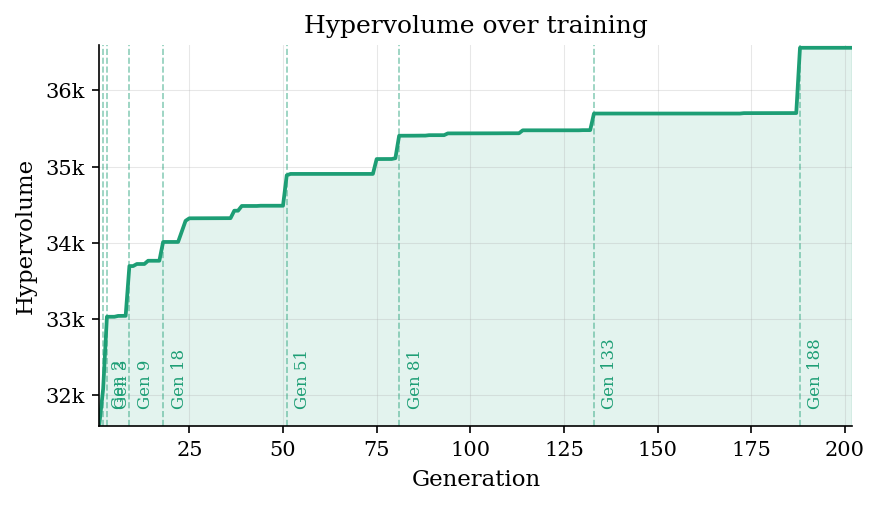

HV gain: 31630 → 36557  (+4927)


In [17]:
fig, ax = plt.subplots(figsize=(6, 3.5))

ax.fill_between(df['generation'], df['hypervolume'], alpha=0.12, color=C_HV)
ax.plot(df['generation'], df['hypervolume'], color=C_HV, linewidth=1.8, label='Hypervolume')

# Annotate key jumps
jumps = df[df['hypervolume'].diff() > 200]
for _, row in jumps.iterrows():
    ax.axvline(row['generation'], color=C_HV, linewidth=0.8, linestyle='--', alpha=0.5)
    ax.text(row['generation'] + 2, df['hypervolume'].min() + 200,
            f"Gen {int(row['generation'])}", fontsize=8, color=C_HV, rotation=90, va='bottom')

ax.set_xlabel('Generation')
ax.set_ylabel('Hypervolume')
ax.set_title('Hypervolume over training')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xlim(1, len(df))
ax.set_ylim(df['hypervolume'].min() * 0.999, df['hypervolume'].max() * 1.001)
fig.tight_layout()
fig.savefig(OUT_DIR / 'hv_curve.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'hv_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'HV gain: {df["hypervolume"].iloc[0]:.0f} → {df["hypervolume"].iloc[-1]:.0f}  (+{df["hypervolume"].iloc[-1]-df["hypervolume"].iloc[0]:.0f})')

## 2 — Crash rate over training

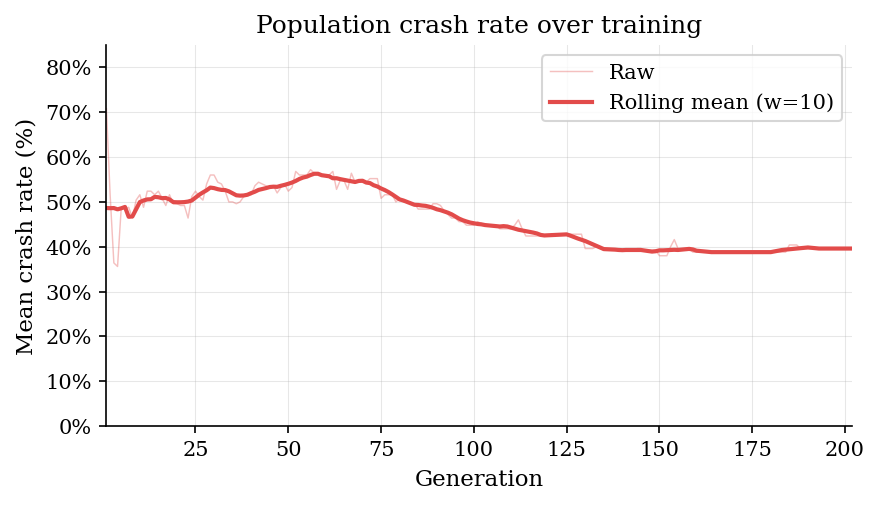

Crash rate: 70.8% → 39.6%


In [18]:
# Smooth with rolling average
window = 10
df['crash_smooth'] = df['crash_pct'].rolling(window, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(6, 3.5))

ax.plot(df['generation'], df['crash_pct'], color=C_CRASH, linewidth=0.7, alpha=0.35, label='Raw')
ax.plot(df['generation'], df['crash_smooth'], color=C_CRASH, linewidth=2.0, label=f'Rolling mean (w={window})')

ax.set_xlabel('Generation')
ax.set_ylabel('Mean crash rate (%)')
ax.set_title('Population crash rate over training')
ax.set_xlim(1, len(df))
ax.set_ylim(0, 85)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'crash_rate.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'crash_rate.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Crash rate: {df["crash_pct"].iloc[0]:.1f}% → {df["crash_pct"].iloc[-1]:.1f}%')

## 3 — All metrics overview (4-panel figure)

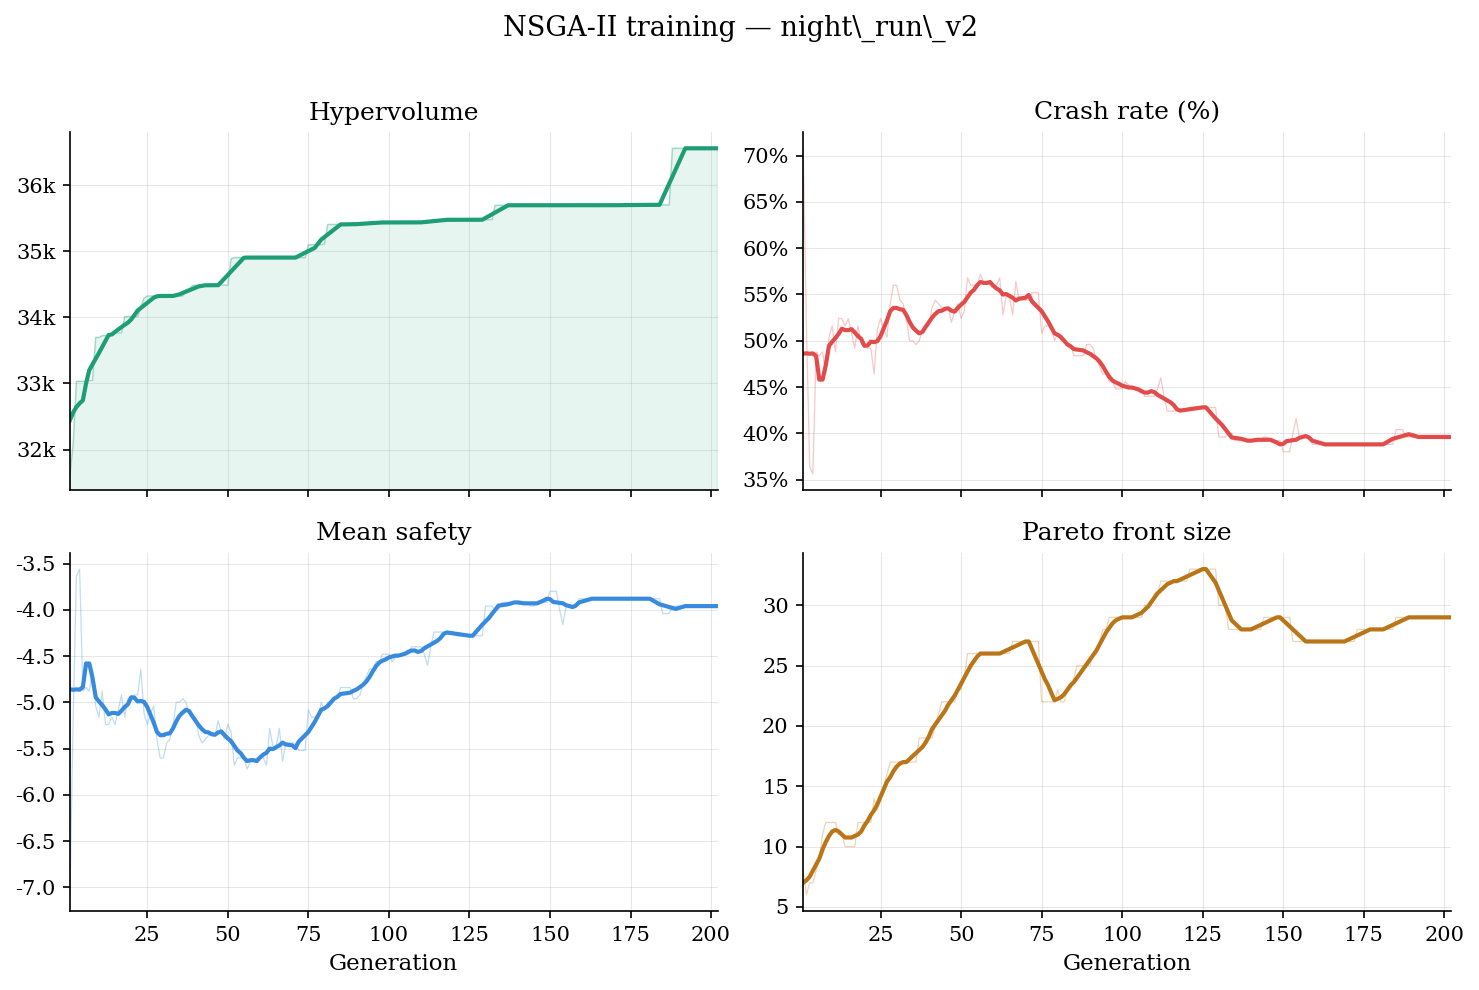

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharex=True)
axes = axes.flatten()

panels = [
    ('hypervolume',   'Hypervolume',          C_HV,     True,  '{:.0f}k', 1000),
    ('crash_pct',     'Crash rate (%)',        C_CRASH,  False, '{:.0f}%', 1),
    ('mean_safety',   'Mean safety',           C_SAFETY, False, '{:.1f}',  1),
    ('pareto_size',   'Pareto front size',     C_PARETO, False, '{:.0f}',  1),
]

for ax, (col, title, color, fill, fmt, divisor) in zip(axes, panels):
    smooth = df[col].rolling(8, center=True, min_periods=1).mean()
    if fill:
        ax.fill_between(df['generation'], df[col], alpha=0.10, color=color)
    ax.plot(df['generation'], df[col],    color=color, linewidth=0.6, alpha=0.30)
    ax.plot(df['generation'], smooth,     color=color, linewidth=2.0)
    ax.set_title(title)
    ax.set_xlim(1, len(df))
    # Zoom y-axis to the data range for all panels
    ymin, ymax = df[col].min(), df[col].max()
    margin = (ymax - ymin) * 0.05
    ax.set_ylim(ymin - margin, ymax + margin)
    if divisor != 1:
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _, d=divisor, f=fmt: f.format(x/d)))
    else:
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _, f=fmt: f.format(x)))

for ax in axes[2:]:
    ax.set_xlabel('Generation')

fig.suptitle('NSGA-II training — night\_run\_v2', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / 'overview_4panel.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'overview_4panel.png', dpi=300, bbox_inches='tight')
plt.show()

## 4 — Dual-axis: HV and crash rate together

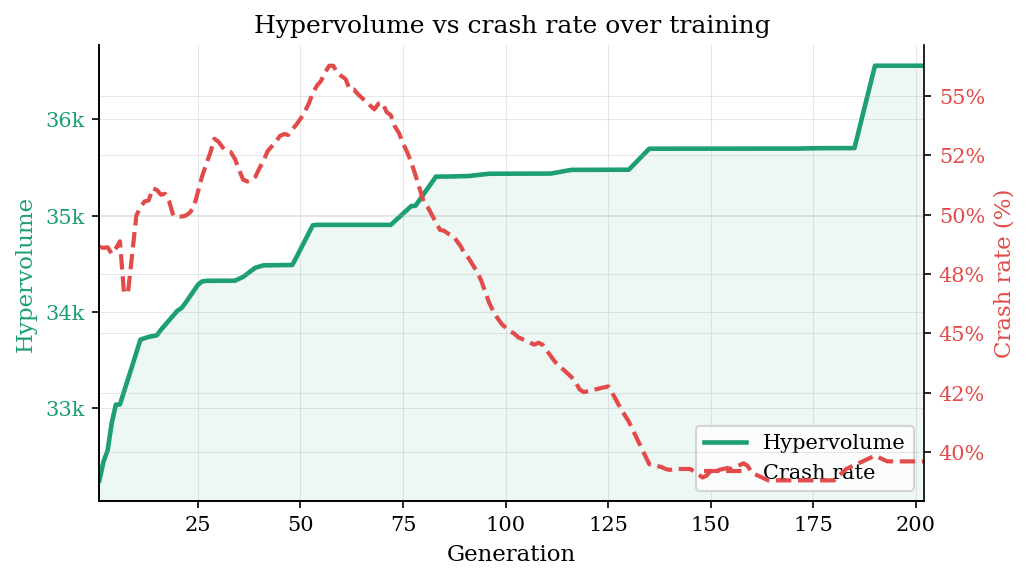

In [20]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

ax2.spines['right'].set_visible(True)
ax2.spines['top'].set_visible(False)

hv_smooth    = df['hypervolume'].rolling(5, center=True, min_periods=1).mean()
crash_smooth = df['crash_pct'].rolling(10, center=True, min_periods=1).mean()

l1, = ax1.plot(df['generation'], hv_smooth,    color=C_HV,    linewidth=2.2, label='Hypervolume')
ax1.fill_between(df['generation'], hv_smooth, alpha=0.08, color=C_HV)

l2, = ax2.plot(df['generation'], crash_smooth, color=C_CRASH, linewidth=2.0, linestyle='--', label='Crash rate')

ax1.set_xlabel('Generation')
ax1.set_ylabel('Hypervolume', color=C_HV)
ax2.set_ylabel('Crash rate (%)', color=C_CRASH)
ax1.tick_params(axis='y', labelcolor=C_HV)
ax2.tick_params(axis='y', labelcolor=C_CRASH)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax1.set_xlim(1, len(df))

# Zoom HV axis to data range
hv_min, hv_max = hv_smooth.min(), hv_smooth.max()
hv_margin = (hv_max - hv_min) * 0.05
ax1.set_ylim(hv_min - hv_margin, hv_max + hv_margin)

ax1.legend(handles=[l1, l2], loc='lower right')
ax1.set_title('Hypervolume vs crash rate over training')
fig.tight_layout()
fig.savefig(OUT_DIR / 'hv_vs_crash.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'hv_vs_crash.png', dpi=300, bbox_inches='tight')
plt.show()

## 5 — Pareto front size and safety evolution

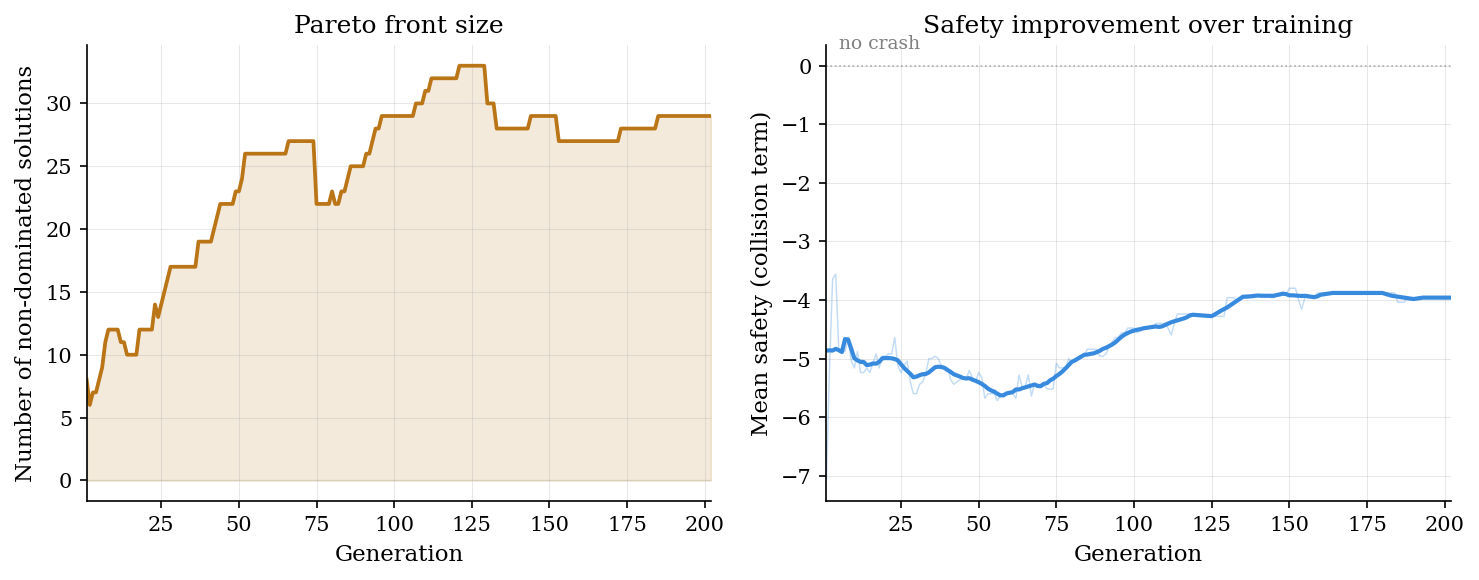

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Pareto front size
ax1.fill_between(df['generation'], df['pareto_size'], alpha=0.15, color=C_PARETO)
ax1.plot(df['generation'], df['pareto_size'], color=C_PARETO, linewidth=1.8)
ax1.set_xlabel('Generation')
ax1.set_ylabel('Number of non-dominated solutions')
ax1.set_title('Pareto front size')
ax1.set_xlim(1, len(df))

# Safety evolution (mean over population)
safety_smooth = df['mean_safety'].rolling(10, center=True, min_periods=1).mean()
ax2.plot(df['generation'], df['mean_safety'],  color=C_SAFETY, linewidth=0.7, alpha=0.3)
ax2.plot(df['generation'], safety_smooth,       color=C_SAFETY, linewidth=2.0)
ax2.axhline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
ax2.text(5, 0.3, 'no crash', fontsize=9, color='gray')
ax2.set_xlabel('Generation')
ax2.set_ylabel('Mean safety (collision term)')
ax2.set_title('Safety improvement over training')
ax2.set_xlim(1, len(df))

fig.tight_layout()
fig.savefig(OUT_DIR / 'pareto_and_safety.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'pareto_and_safety.png', dpi=300, bbox_inches='tight')
plt.show()

## 6 — Safety penalty vs Smoothness penalty

Two distinct metrics :
- **`crash_pct`** — *frequency*: percentage of agents in the population that crash each generation.
- **`safety_penalty`** — *intensity*: mean weighted collision term from the safety objective (inverted sign → lower is safer).
- **`smoothness_penalty`** — mean combined accel + jerk + stable-speed penalty (inverted sign → lower is smoother).

Both penalty curves decrease toward 0 as the population improves.

In [ ]:
checkpoints = [1, 25, 50, 100, 150, 202]
rows = []
for g in checkpoints:
    row = df[df['generation'] == g].iloc[0]
    rows.append({
        'Generation':       int(g),
        'Hypervolume':      f"{row['hypervolume']:.0f}",
        'Crash rate':       f"{row['crash_pct']:.1f}%",
        'Safety penalty':   f"{row['safety_penalty']:.2f}",   # positive, lower = safer
        'Smooth. penalty':  f"{row['smoothness_penalty']:.2f}", # positive, lower = smoother
        'Mean speed':       f"{row['mean_speed']:.2f}",
        'Pareto size':      int(row['pareto_size']),
        'Elapsed':          f"{row['elapsed_min']:.0f} min",
    })

summary = pd.DataFrame(rows)
print("(Safety & smoothness penalties: positive values, lower = better)\n")
print(summary.to_string(index=False))
print()
print('--- LaTeX table ---')
print(summary.to_latex(index=False, escape=False))

## 6 — Summary statistics table

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

hv_smooth = df['hypervolume'].rolling(5, center=True, min_periods=1).mean()
ax.fill_between(df['generation'], hv_smooth, alpha=0.10, color=C_HV)
ax.plot(df['generation'], hv_smooth, color=C_HV, linewidth=2.2)

# Annotate phases
phases = [
    (1,   50,  '#E6F1FB', 'Phase 1\nRapid exploration'),
    (51,  130, '#EAF3DE', 'Phase 2\nConsolidation'),
    (131, 202, '#FAEEDA', 'Phase 3\nRefinement'),
]
hv_min, hv_max = hv_smooth.min(), hv_smooth.max()
hv_margin = (hv_max - hv_min) * 0.05
ymin, ymax = hv_min - hv_margin, hv_max + hv_margin

for (x0, x1, color, label) in phases:
    ax.axvspan(x0, x1, alpha=0.25, color=color, zorder=0)
    ax.text((x0 + x1) / 2, ymin + (ymax - ymin) * 0.05,
            label, ha='center', fontsize=9, color='#444441')

ax.set_xlabel('Generation')
ax.set_ylabel('Hypervolume')
ax.set_title('Training phases — NSGA-II')
ax.set_xlim(1, len(df))
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}k'))
fig.tight_layout()
fig.savefig(OUT_DIR / 'hv_phases.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'hv_phases.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figures saved to:', OUT_DIR.resolve())

## 7 — Key phases annotation

Identify the main learning phases from the HV curve.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

hv_smooth = df['hypervolume'].rolling(5, center=True, min_periods=1).mean()
ax.fill_between(df['generation'], hv_smooth, alpha=0.10, color=C_HV)
ax.plot(df['generation'], hv_smooth, color=C_HV, linewidth=2.2)

# Annotate phases
phases = [
    (1,   50,  '#E6F1FB', 'Phase 1\nRapid exploration'),
    (51,  130, '#EAF3DE', 'Phase 2\nConsolidation'),
    (131, 202, '#FAEEDA', 'Phase 3\nRefinement'),
]
ymin, ymax = hv_smooth.min() - 200, hv_smooth.max() + 200
for (x0, x1, color, label) in phases:
    ax.axvspan(x0, x1, alpha=0.25, color=color, zorder=0)
    ax.text((x0 + x1) / 2, ymin + (ymax - ymin) * 0.05,
            label, ha='center', fontsize=9, color='#444441')

ax.set_xlabel('Generation')
ax.set_ylabel('Hypervolume')
ax.set_title('Training phases — NSGA-II')
ax.set_xlim(1, len(df))
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}k'))
fig.tight_layout()
fig.savefig(OUT_DIR / 'hv_phases.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'hv_phases.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figures saved to:', OUT_DIR.resolve())